# Building a Neural Network from Scratch

From basic calculus to a working multi-layer neural network. No PyTorch, no TensorFlow, just Python.

### What is a neural network?

A neural network is a function that learns from examples. You give it inputs (numbers) and it produces an output (a number). What makes it different from a regular function is that it has thousands of adjustable **parameters** (weights and biases) that control its behavior. With random parameters, the output is meaningless. With the *right* parameters, it can classify images, translate languages, or generate text.

But nobody sets those parameters by hand. Instead, you show the network examples of correct input/output pairs and let it figure out the right values on its own. This is **training**: you feed in an example, compare the network's output to the right answer, measure how wrong it was, and then adjust each parameter a tiny bit in the direction that makes the answer less wrong. Do this thousands of times and the parameters gradually converge to values that produce useful outputs.

The question is: when you have thousands of parameters, how do you know which ones to adjust and by how much? That's where **derivatives** come in. A derivative tells you, for each parameter individually, "if I nudge this one up a little, does the error get bigger or smaller, and by how much?" That signal is all you need. Nudge each parameter in the direction that reduces the error, and the network improves.

This notebook builds every piece of that system from scratch:

| Step | What we build | Key concept |
|------|--------------|-------------|
| 1 | Numerical derivatives | How inputs affect outputs |
| 2 | Value class | Tracking computations + automatic gradients |
| 3 | Complete Value class | All arithmetic with gradients |
| 4 | A single neuron | Weights, bias, activation |
| 5 | Layers and networks | Multi-layer perceptron |
| 6 | Training | Loss function + gradient descent |
| 7 | Optimizations | Learning rate decay, regularization, mini-batches |
| 8 | Decision boundary | Visualizing what the network learned |

We only need Python's `random` for the neural network itself. `numpy`, `scikit-learn`, and `matplotlib` show up later for data generation and plotting.

In [11]:
import random
import numpy as np
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1: Derivatives — The Training Signal

**The problem:** A neural network has hundreds of weights, all initialized to random values. After making a wrong prediction, we need to adjust those weights to reduce the error. But which ones? And by how much?

**The solution:** For each weight, compute its **derivative** with respect to the error. The derivative answers: "if I increase this weight slightly, does the error go up or down, and by how much?" That's the signal we need to adjust it in the right direction.

### Computing a derivative numerically

The simplest approach: nudge the weight by a tiny amount `h`, measure how much the error changes, and divide by `h`:

```
derivative = (error with weight + h) - (error with weight) / h
```

The division normalizes the change — same idea as speed (distance / time).

**Why `h` must be tiny:** The derivative is the slope *at a point*, not the average slope over a range. Most functions curve, so a large `h` measures the average between two distant points rather than the exact slope at either one.

Example: `f(x) = x²` at `x = 3`
- Exact derivative: `6.0`
- With `h = 1.0`: `(16 - 9) / 1 = 7.0` (too large, the curve distorts it)
- With `h = 0.0001`: `6.0001` (close to exact)

### Partial derivatives for multiple weights

A neural network has many weights (this one will have 337). You can compute each weight's derivative independently by nudging it while holding all others fixed. Each result is a **partial derivative** — the error's sensitivity to that specific weight.

**The cost:** With 337 weights, you'd need 337 forward passes through the network per training step. Far too slow.

Below we compute derivatives numerically for two toy functions to build intuition. **We won't use this approach in the actual network.** Step 2 shows how to get all 337 derivatives in a single pass.

In [12]:
# Single variable: f(x) = x² + 3x
def f(x):
    return x**2 + 3*x

x = 2.0
h = 0.0001  # tiny nudge
slope = (f(x + h) - f(x)) / h
print(f'f({x}) = {f(x)}')          # 10.0
print(f'slope at x={x}: {slope:.4f}')  # exact: 2x + 3 = 7

# Multiple variables: nudge one at a time to get partial derivatives
def g(a, b):
    return a * b + a**2

a, b = 3.0, 2.0
print(f'\ng({a}, {b}) = {g(a, b)}')                       # 15.0
print(f'dg/da = {(g(a+h, b) - g(a, b)) / h:.4f}')  # exact: b + 2a = 8
print(f'dg/db = {(g(a, b+h) - g(a, b)) / h:.4f}')  # exact: a = 3

f(2.0) = 10.0
slope at x=2.0: 7.0001

g(3.0, 2.0) = 15.0
dg/da = 8.0001
dg/db = 3.0000


## Step 2: Backpropagation — Computing All Derivatives at Once

### The core idea

Step 1's nudging approach works but doesn't scale (337 weights = 337 forward passes per update). **Backpropagation** solves this:

1. **Forward pass:** Compute the network's output, recording every arithmetic operation in a graph
2. **Backward pass:** Walk the graph in reverse, computing the gradient of every weight in one sweep

Result: one forward pass, one backward pass, all 337 derivatives computed.

### How it works

**The computation graph:** As you compute `d = (a + b) * b`, each operation creates a node that remembers its inputs:

```
a = 2.0
b = 3.0
c = a + b          # c knows it came from (a, b, +)
d = c * b          # d knows it came from (c, b, *)
```

**The backward pass:** Start at the output (`d`) and work back using the **chain rule**. At each node, multiply the local derivative by the gradient from downstream:

| Node | Local derivative | Computation | Result |
|------|-----------------|-------------|--------|
| `d` (start) | — | `d.grad = 1.0` | Output's derivative wrt itself is always 1 |
| `d = c * b` | `dd/dc = b`<br>`dd/db = c` | `c.grad += 3 * 1.0`<br>`b.grad += 5 * 1.0` | `c.grad = 3.0`<br>`b.grad = 5.0` |
| `c = a + b` | `dc/da = 1`<br>`dc/db = 1` | `a.grad += 1 * 3.0`<br>`b.grad += 1 * 3.0` | `a.grad = 3.0`<br>`b.grad = 8.0` |

**Why `b.grad = 8.0`:** `b` appears in two operations (`a + b` and `c * b`), so it gets gradient contributions from both paths (5.0 + 3.0 = 8.0). This is why gradients use `+=` — weights in a neural network feed into multiple computations, and the total derivative is the sum of all paths.

### The chain rule in plain terms

For a chain of operations like `loss = f(g(h(weight)))`, the derivative of the loss with respect to the weight is:

```
dLoss/dWeight = dLoss/df * df/dg * dg/dh * dh/dWeight
```

Each factor is a local derivative that one operation knows. Multiply them together (the chain rule) and you get the total derivative. Backpropagation automates this by storing each operation's local derivative rule and multiplying them in reverse order.

### Why this is efficient

- **Reuses forward pass values:** The backward pass needs `a`, `b`, `c` values that were already computed going forward
- **One sweep:** Instead of 337 separate nudges, walk the graph once and every weight gets its gradient
- **Scales to any size:** 337 weights or 337 million, it's still one forward + one backward pass

### Implementation

The `Value` class below wraps every number in the network. Each operation (`+`, `*`) creates a new `Value` that stores:
- `data`: the result
- `_prev`: which Values were used as inputs
- `_backward`: a closure with the local derivative rule for this operation

The `backward()` method topologically sorts the graph and calls each `_backward` in reverse order, propagating gradients from output to inputs.

In [13]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # d(a+b)/da = 1, d(a+b)/db = 1
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # d(a*b)/da = b, d(a*b)/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort — process each node after all its consumers
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [14]:
# d = (a + b) * b — note that b appears twice
a = Value(2.0)
b = Value(3.0)
c = a + b   # 5
d = c * b   # 15
d.backward()

print(f'd = {d.data}')
print(f'a.grad = {a.grad}')  # dd/da = b = 3
print(f'b.grad = {b.grad}')  # dd/db = a + 2b = 8 (b used twice, gradients accumulate)

# Verify against the numerical approach
h = 0.0001
fn = lambda a, b: (a + b) * b
print(f'\nNumerical dd/da = {(fn(2+h, 3) - fn(2, 3)) / h:.4f}')
print(f'Numerical dd/db = {(fn(2, 3+h) - fn(2, 3)) / h:.4f}')

d = 15.0
a.grad = 3.0
b.grad = 8.0

Numerical dd/da = 3.0000
Numerical dd/db = 8.0001


## Step 3: Completing the Value class

Our Value class only supports `+` and `*` so far. To build a neural network we need a few more operations:

- **Power** (`**`): we need this for division. `a / b` is really just `a * b⁻¹`, i.e. `a * b**-1`. So if we have power, we get division for free.
- **Reverse operators** (`__radd__`, `__rmul__`, etc.): Python plumbing so that `3 * Value(2)` works, not only `Value(2) * 3`.

### ReLU

ReLU is the most important addition. It stands for Rectified Linear Unit, but all it does is `max(0, x)`:

```
relu( 3.0) =  3.0    positive input, passes through unchanged
relu(-2.0) =  0.0    negative input, clamped to zero
relu( 0.1) =  0.1    positive input, passes through unchanged
```

Why do we need this? Without ReLU, every operation in our network is linear (additions and multiplications). A chain of linear operations always collapses into a single linear operation, no matter how many layers you stack. That means a 100-layer network would be no more powerful than a 1-layer network. ReLU breaks this by introducing a nonlinearity: it bends the output at zero. This is what allows the network to learn curves and complex shapes instead of just straight lines.

**What ReLU does to the gradient:** ReLU acts as a gate during backpropagation. The decision is based on whether the *input* to ReLU was positive or negative during the forward pass:

- **Input was positive** (ReLU passed it through): the gate is open. The gradient from downstream flows straight through, unchanged. It doesn't matter whether that gradient is positive or negative, both pass through. The derivative is 1.
- **Input was negative** (ReLU clamped it to zero): the gate is closed. The gradient is blocked entirely. No signal reaches the weights behind this neuron, so they don't get updated. The derivative is 0.

This means ReLU has two effects during training. It shapes the output (zeroing out negative scores), and it controls which parts of the network get updated (only neurons whose weighted sum was positive receive gradient signal). Different inputs activate different neurons, which is how the network learns to treat different inputs differently.

In [15]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            # Power rule: d(x^n)/dx = n * x^(n-1)
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')
        def _backward():
            # Passes gradient through if input > 0, blocks it otherwise
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __neg__(self):            return self * -1
    def __sub__(self, other):     return self + (-other)
    def __truediv__(self, other): return self * other**-1
    def __radd__(self, other):    return self + other
    def __rsub__(self, other):    return other + (-self)
    def __rmul__(self, other):    return self * other
    def __rtruediv__(self, other): return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [16]:
# Test the new operations
x = Value(3.0)
print(f'x**2 = {(x**2).data}, relu(-x) = {(-x).relu().data}, 6/x = {(6/x).data}')

# Gradients through a chain: relu(a*b + 10)
a = Value(2.0)
b = Value(-3.0)
c = (a * b + 10).relu()  # relu(-6 + 10) = 4
c.backward()
print(f'relu(a*b + 10) = {c.data}, a.grad = {a.grad}, b.grad = {b.grad}')

x**2 = 9.0, relu(-x) = 0, 6/x = 2.0
relu(a*b + 10) = 4.0, a.grad = -3.0, b.grad = 2.0


## Step 4: A single neuron

Now we put the Value class to work. A neuron is the basic building block of a neural network. It takes some inputs, decides how important each one is, and produces a single output:

```
   x₁ ──w₁──┐
   x₂ ──w₂──┤──[ Σ + b ]──[ ReLU ]──→ output
   x₃ ──w₃──┘
```

Think of it as a tiny decision-maker. Each **weight** is an opinion about how much a particular input matters: a large positive weight means "this input is strong evidence *for*", a negative weight means "this is evidence *against*". The **bias** shifts where the threshold is. It lets the neuron fire (or not) even when all inputs are zero.

To make this concrete, say a neuron has weights `[0.5, -0.3]` and bias `0.1`, and receives inputs `[4.0, 2.0]`:

```
weighted sum = 0.5 * 4.0 + (-0.3) * 2.0 + 0.1
             = 2.0 - 0.6 + 0.1
             = 1.5
relu(1.5)    = 1.5  (positive, passes through)
```

The neuron outputs 1.5. It "fires" for this input because the weighted sum came out positive. If the inputs had been different and the sum came out negative, ReLU would have clamped it to zero, and this neuron would contribute nothing to the network's output for that data point.

The weights start at random values. The neuron has no idea what it's doing yet. But because weights and bias are `Value` objects, gradients flow through them automatically. After calling `backward()`, every weight knows: "if I were a little bigger, the final loss would go up/down by this much." That's the signal the training loop uses to adjust each weight in the right direction.

In [21]:
class Neuron:

    def __init__(self, n_inputs, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

In [22]:
random.seed(42)
neuron = Neuron(3)
print(f'{neuron}, weights: {[round(w.data, 3) for w in neuron.w]}')

x = [Value(1.0), Value(-1.0), Value(0.5)]
output = neuron(x)
output.backward()

# The weighted sum is 0.279*1.0 + (-0.95)*(-1.0) + (-0.45)*0.5 + 0 = 1.004
# That's positive, so ReLU passes it through unchanged (output = 1.004).
# If the sum had been negative, ReLU would clamp to zero and block all gradients.
print(f'output = {output.data:.4f}')

# Each gradient equals its corresponding input. Why? Because d(w*x)/dw = x,
# and ReLU's derivative is 1 (it passed through), so the chain rule gives x * 1 = x.
for i, w in enumerate(neuron.w):
    print(f'  w{i}.grad = {w.grad:.4f}  (input was {x[i].data})')

ReLUNeuron(3), weights: [0.279, -0.95, -0.45]
output = 1.0039
  w0.grad = 1.0000  (input was 1.0)
  w1.grad = -1.0000  (input was -1.0)
  w2.grad = 0.5000  (input was 0.5)


## Step 5: Layers and networks

One neuron can only learn simple things. With 2D inputs (like x, y coordinates), a single neuron draws one straight line through the space: everything on one side gets a positive score, everything on the other side gets zero. That's it. A single neuron could learn "points in the top-right tend to be class +1", but it could never learn "points inside a circle are class -1" because that's not a straight line.

To learn complex shapes, you need to combine neurons. The trick is two levels of composition:

A **Layer** is a group of neurons that all see the same inputs. Each neuron has its own weights, so each one draws a *different* line through the input space. One neuron might split left from right, another might split top from bottom, another might split along a diagonal. You get multiple perspectives on the same data.

An **MLP** (multi-layer perceptron) stacks multiple layers. Layer 1's outputs feed into layer 2 as inputs, and so on. This is where things get interesting. Layer 1 neurons each draw a straight line, outputting "am I above or below my line?" The layer 2 neurons receive these yes/no-ish signals and can combine them: "if neuron 1 says yes AND neuron 3 says yes AND neuron 5 says no, then..." By combining enough straight-line decisions, the network can carve out curved regions, rings, blobs, or whatever shape the data requires.

We also introduce a **Module** base class. It gives us two things we'll need for training: `parameters()` collects every trainable weight in the entire network into one flat list, and `zero_grad()` resets all gradients to zero between training steps (gradients accumulate with `+=`, so if you don't reset them, they pile up from previous steps).

One detail: the last layer has no ReLU activation. Its job is to produce a raw score, positive means "I think class +1", negative means "class -1". If we put ReLU on the output, it would clamp all negative scores to zero, and the model could never express "I'm confident this is NOT class +1."

In [23]:
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []


class Neuron(Module):

    def __init__(self, n_inputs, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


class Layer(Module):

    def __init__(self, n_inputs, n_outputs, **kwargs):
        self.neurons = [Neuron(n_inputs, **kwargs) for _ in range(n_outputs)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):

    def __init__(self, n_inputs, layer_sizes):
        sz = [n_inputs] + layer_sizes
        # Last layer has no activation (raw output for the loss function)
        self.layers = [
            Layer(sz[i], sz[i+1], nonlin=(i != len(layer_sizes) - 1))
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [24]:
random.seed(42)
model = MLP(2, [16, 16, 1])  # 2 inputs → 16 → 16 → 1 output
print(model)
print(f'{len(model.parameters())} parameters')

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
337 parameters


## Step 6: Training

We have a network with 337 parameters, all initialized to random values. If you feed it a data point right now, it outputs a meaningless number. Training is the process of adjusting those 337 knobs until the network starts producing useful outputs.

But "useful" is vague. We need to be precise about what we want the network to do, and we need a way to measure how far off it is. That's what the next few cells set up, one piece at a time.

### The dataset

We need data to train on. We generate 100 points arranged in two concentric circles: an inner ring (labeled -1) and an outer ring (labeled +1). We want the network to learn: given a point's coordinates, is it in the inner ring or the outer ring?

This problem is deliberately impossible for a simple linear classifier. No straight line can separate the inside of a circle from the outside. The network will need to use its nonlinear ReLU activations to learn a curved boundary.

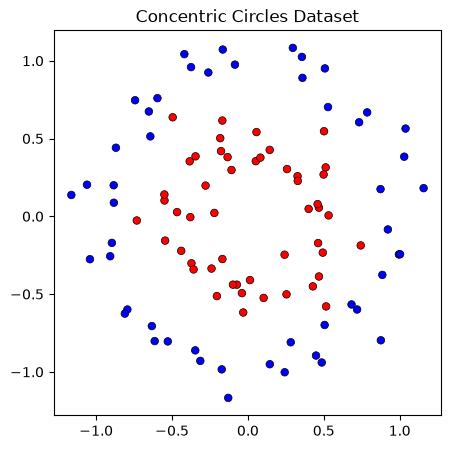

In [25]:
np.random.seed(42)
random.seed(42)

# Inner ring = class -1, outer ring = class +1
X, y = make_circles(n_samples=100, noise=0.1, factor=0.5)
y = y * 2 - 1

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr', edgecolors='k', linewidth=0.5)
plt.title('Concentric Circles Dataset')
plt.show()

### The loss function

The network outputs a single number for each point. Positive means "I think this is the outer ring (+1)", negative means "I think this is the inner ring (-1)." But how do we tell the network *how wrong* it is? We need a single number that captures that: the **loss**.

We use the **hinge loss**: `max(0, 1 - y * prediction)`. To see why this works, walk through a few cases. Say the true label is `y = +1` (outer ring):

- Prediction = **2.5** (correct, confident): `max(0, 1 - 1*2.5)` = `max(0, -1.5)` = **0**. No loss. The model got it right and was sure about it.
- Prediction = **0.3** (correct, but barely): `max(0, 1 - 1*0.3)` = `max(0, 0.7)` = **0.7**. Some loss. The model guessed right but wasn't confident, and we want it to commit.
- Prediction = **-1.0** (wrong): `max(0, 1 - 1*(-1.0))` = `max(0, 2.0)` = **2.0**. Big loss. The model was wrong *and* confident about it.

The `max(0, ...)` is our old friend `relu()`. The loss is zero when the model is correct and confident, and grows as predictions get worse. We average this over all data points to get one number for the whole batch.

### The training loop

Now we have everything: a model that produces predictions, and a loss function that scores how wrong those predictions are. Training is a loop:

1. **Forward pass**: feed every data point through the network and collect predictions.
2. **Compute the loss**: run the predictions through the hinge loss formula to get a single number.
3. **Backward pass**: call `loss.backward()`. This walks the computation graph in reverse (the autograd we built in Step 2) and fills in `.grad` on every single parameter in the network. Each gradient says: "if you increased this weight by a tiny amount, the loss would go up/down by this much."
4. **Update the weights**: for each parameter, subtract a small fraction of its gradient. This is **gradient descent**: the gradient points toward *more* loss, so we step in the opposite direction. The fraction is called the **learning rate**, and it controls how aggressive each step is.
5. **Reset gradients**: call `model.zero_grad()` before the next backward pass, because gradients accumulate with `+=` and we don't want leftovers from the previous step.

Then repeat. Each iteration, the loss should get a little smaller and the accuracy a little higher.

In [26]:
def train(model, X, y, steps=100, lr=0.5, lr_decay=False, l2_alpha=0, batch_size=None):
    for step in range(steps):
        # Select batch
        if batch_size:
            idx = np.random.permutation(len(X))[:batch_size]
            Xb, yb = X[idx], y[idx]
        else:
            Xb, yb = X, y

        # Forward pass
        preds = [model([Value(float(x[0])), Value(float(x[1]))]) for x in Xb]

        # Hinge loss: max(0, 1 - y * prediction)
        losses = [(1 + -yi * pred).relu() for yi, pred in zip(yb, preds)]
        loss = sum(losses) * (1.0 / len(losses))
        if l2_alpha:
            loss = loss + l2_alpha * sum(p * p for p in model.parameters())

        acc = sum((yi > 0) == (p.data > 0) for yi, p in zip(yb, preds)) / len(yb)

        # Backward pass + SGD update
        model.zero_grad()
        loss.backward()

        rate = lr * (1 - 0.9 * step / steps) if lr_decay else lr
        for p in model.parameters():
            p.data -= rate * p.grad

        if step % 10 == 0 or step == steps - 1:
            print(f'Step {step:3d}  loss={loss.data:.4f}  accuracy={acc*100:.0f}%')

# Train with vanilla SGD
random.seed(42)
model = MLP(2, [16, 16, 1])
print(f'{len(model.parameters())} parameters\n')
train(model, X, y, lr=0.5)

337 parameters

Step   0  loss=1.1909  accuracy=51%
Step  10  loss=0.8099  accuracy=52%
Step  20  loss=0.4487  accuracy=79%
Step  30  loss=0.1265  accuracy=98%
Step  40  loss=0.0697  accuracy=99%
Step  50  loss=0.0513  accuracy=99%
Step  60  loss=0.0397  accuracy=99%
Step  70  loss=0.0374  accuracy=99%
Step  80  loss=0.0364  accuracy=99%
Step  90  loss=0.0360  accuracy=99%
Step  99  loss=0.0272  accuracy=100%


In [ ]:
# Test the trained model on a few specific points
inner_point = X[y == -1][0]  # a point from the inner ring
outer_point = X[y == 1][0]   # a point from the outer ring

inner_pred = model([Value(float(inner_point[0])), Value(float(inner_point[1]))])
outer_pred = model([Value(float(outer_point[0])), Value(float(outer_point[1]))])

print(f'Inner ring point {inner_point.round(2)} → prediction: {inner_pred.data:.3f} (should be negative)')
print(f'Outer ring point {outer_point.round(2)} → prediction: {outer_pred.data:.3f} (should be positive)')

## Step 7: Optimizations

Vanilla gradient descent works, but it has some problems that show up in practice. Here are three simple improvements. Each one adds a single parameter to the `train()` call.

### Learning rate decay

The learning rate controls how big each weight update is. A fixed rate is a problem: if it's large, the model makes fast progress early on but once it gets close to a good solution, it keeps overshooting. You'll see the loss jumping around (0.05, 0.08, 0.04, 0.09) instead of settling down. If the rate is small, it converges smoothly but takes forever to get there.

Learning rate decay gives you both: start with a large rate for fast initial progress, then gradually shrink it so the model can settle into a precise minimum. In the code, the rate starts at 1.0 and decays to 0.1 over the course of training.

In [27]:
random.seed(42)
model = MLP(2, [16, 16, 1])
train(model, X, y, lr=1.0, lr_decay=True)

Step   0  loss=1.1909  accuracy=51%
Step  10  loss=0.5152  accuracy=82%
Step  20  loss=0.3947  accuracy=84%
Step  30  loss=0.1510  accuracy=94%
Step  40  loss=0.0589  accuracy=97%
Step  50  loss=0.0497  accuracy=97%
Step  60  loss=0.0404  accuracy=99%
Step  70  loss=0.0355  accuracy=99%
Step  80  loss=0.0313  accuracy=100%
Step  90  loss=0.0284  accuracy=100%
Step  99  loss=0.0271  accuracy=100%


### L2 regularization

Without any constraints, the model is free to crank certain weights up to huge values to perfectly nail every single training point, including the noise. This is **overfitting**: it aces the training set but falls apart on new data, because it memorized the noise instead of learning the real pattern.

L2 regularization is a simple fix: add a penalty to the loss that's proportional to the sum of squared weights. A weight of 10.0 contributes 100 to the penalty, while a weight of 1.0 contributes just 1. This pushes the model toward smaller, more balanced weights. Smaller weights produce smoother decision boundaries, which tend to generalize better to data the model hasn't seen before.

The `l2_alpha` parameter controls the trade-off: too high and you constrain the model so much it can't learn the pattern, too low and it has no effect. A value like `1e-4` is a common starting point.

In [28]:
random.seed(42)
model = MLP(2, [16, 16, 1])
train(model, X, y, lr=1.0, lr_decay=True, l2_alpha=1e-4)

Step   0  loss=1.2015  accuracy=51%
Step  10  loss=0.5387  accuracy=80%
Step  20  loss=0.3875  accuracy=84%
Step  30  loss=0.2056  accuracy=92%
Step  40  loss=0.0612  accuracy=98%
Step  50  loss=0.0566  accuracy=99%
Step  60  loss=0.0514  accuracy=100%
Step  70  loss=0.0563  accuracy=98%
Step  80  loss=0.0482  accuracy=100%
Step  90  loss=0.0439  accuracy=100%
Step  99  loss=0.0425  accuracy=100%


### Mini-batch training

So far, every training step feeds *all* 100 samples through the network, computes the loss over all of them, then updates the weights once. That's fine with 100 data points, but real datasets have millions. You'd wait ages for a single weight update.

Mini-batch training grabs a random subset (say, 20 samples) each step. The gradient you compute is noisier, since it's based on a sample rather than the full dataset, but each step is much faster. Over many steps, the model sees all the data, just in different random combinations each time.

Surprisingly, the noise often *helps*. A gradient computed from 20 random samples points in roughly the right direction but not exactly. This randomness makes it harder for the model to memorize specific data points, which acts like a built-in regularizer. Mini-batches of 16 to 64 are the standard in practice, even when you *could* afford full-batch training.

Notice in the output below that the accuracy jumps around more than in the full-batch runs. That's the noise from sampling. The trend is still downward, it's just bumpier.

In [29]:
random.seed(42)
np.random.seed(42)
model = MLP(2, [16, 16, 1])
train(model, X, y, lr=1.0, lr_decay=True, l2_alpha=1e-4, batch_size=20)

Step   0  loss=1.3653  accuracy=50%
Step  10  loss=0.4387  accuracy=90%
Step  20  loss=0.8916  accuracy=70%
Step  30  loss=0.5158  accuracy=70%
Step  40  loss=0.2038  accuracy=100%
Step  50  loss=0.1146  accuracy=95%
Step  60  loss=0.2200  accuracy=85%
Step  70  loss=0.1067  accuracy=95%
Step  80  loss=0.0487  accuracy=100%
Step  90  loss=0.0437  accuracy=100%
Step  99  loss=0.0376  accuracy=100%


## Step 8: Visualizing the decision boundary

Training shows the loss going down and accuracy going up, but that's just numbers. What did the network actually *learn*? To see it, we evaluate the model on a dense grid of points covering the entire input space and color each point by the model's prediction: blue for class -1 (inner ring), red for class +1 (outer ring).

The boundary between red and blue is the decision surface. For our concentric circles, a good boundary should look roughly circular, separating the inner region from the outer one. If training worked, you should see the data points sitting cleanly in their matching colored regions.

Look at the shape of the boundary. It's not a perfect circle. It's made of straight-edged segments. That's because each ReLU neuron can only draw a straight line. The network approximates the curve by combining many straight lines at different angles, like building a circle out of small straight pieces. More neurons in the hidden layers would produce a smoother boundary.

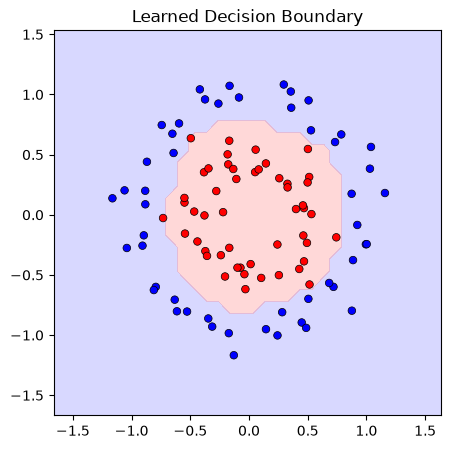

In [30]:
h = 0.1
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_grid = np.c_[xx.ravel(), yy.ravel()]

scores = [model([Value(float(pt[0])), Value(float(pt[1]))]) for pt in X_grid]
Z = np.array([s.data > 0 for s in scores]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr', edgecolors='k', linewidth=0.5)
plt.title('Learned Decision Boundary')
plt.show()

## Summary

What we built, and how it connects:

| Component | What it does |
|-----------|-------------|
| `Value` | Wraps a number, records every operation, computes all derivatives in one backward pass |
| `Neuron` | Weighted sum of inputs + bias + ReLU |
| `Layer` / `MLP` | Groups neurons into layers, chains layers into a network |
| `train()` | The learning loop: forward, loss, backward, nudge weights, repeat |

The whole thing traces back to Step 1. Training a neural network is just computing derivatives (how does each knob affect the error?) and then turning the knobs to reduce that error. The Value class automates the derivative computation, the network classes organize the knobs, and the training loop does the turning.

This is how PyTorch works under the hood: same autograd, same backpropagation. The difference is scale. PyTorch operates on tensors (big arrays of numbers) on GPUs instead of individual scalars. The [transformer notebook](../transformer/notebook.ipynb) builds a GPT using PyTorch, applying everything from this notebook at a much larger scale.

### A note on dying ReLU

There's a subtle problem with ReLU: if a neuron's weights land in a state where the weighted sum is negative for *every* input in the dataset, its gradient is always zero, so the weights never get updated. The neuron is permanently dead. This can happen from unlucky random initialization, or from a learning rate that's too large (a big update overshoots and pushes the weights into a region where the neuron never fires again).

Common fixes in practice:

- **Leaky ReLU**: instead of `max(0, x)`, use `max(0.01x, x)`. Negative inputs get a small slope instead of flat zero, so the gradient is 0.01 instead of 0. Tiny, but enough for the weights to keep moving.
- **Better initialization**: schemes like He initialization scale the random weights based on the number of inputs, reducing the chance of neurons starting dead.
- **Lower learning rates**: smaller updates are less likely to catapult weights into a permanently negative region.

Our notebook uses plain ReLU because it's the simplest to understand and works fine for a small network with 100 data points. In larger networks, dying neurons become a real concern.